# Test zavolab_pyutils Module

Testing the `read_count_data_analysis` module with sample data

In [374]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# this is important to be able to re-import the module after making modifications to the zavolab_pyutils code on Scicore

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from zavolab_pyutils.read_count_simulation import simulate_negative_binomial_counts, simulate_poisson_lognormal_counts
from zavolab_pyutils.read_count_data_analysis import apply_deseq2_normalization, model_mean_variance, apply_sanity_normalization, test_differential_expression, get_deseq2_means_and_errors
from zavolab_pyutils.visualization import plot_size_factors, plot_mean_variance_diagnostics, plot_gene_expression_with_ci, plot_mean_vs_cv, plot_expr_vs_libsize_correlation, plot_sanity_gene_expression_with_ci, plot_variance_vs_expression

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [191]:
?apply_deseq2_normalization

Signature:
apply_deseq2_normalization(
    counts_df,
    metadata_df,
    sample_col='sample',
    cond_col='condition',
    lowExprGenesQ=0.3,
    pseudocount=1,
)
Docstring:
Performs DESeq2-style median-of-ratios normalization.

Parameters
----------
counts_df : pd.DataFrame
    Raw count matrix (genes x samples). May contain additional annotation columns.
metadata_df : pd.DataFrame
    Metadata mapping samples to biological conditions.
sample_col : str, optional
    Column name in metadata_df containing sample IDs. Default is 'sample'.
cond_col : str, optional
    Column name in metadata_df containing condition labels. Default is 'condition'.
lowExprGenesQ : float, optional
    Quantile specifying the threshold to discard low-expressed genes 
    for size factor calculation. Default is 0.3.
pseudocount : float, optional
    Added count before dividing by size factor value. Essential if further 
    log transformation is performed. Default is 1.

Returns
-------
norm_counts_df : pd.

## Create sample count data

In [81]:
# we generate the data under assumption of NO differentially expressed genes, so any significant changes between conditions are false positives!

In [208]:
# Generate DESeq2-style data (Poisson-Gamma)
nb_counts_df, metadata_df, nb_true_sf = simulate_negative_binomial_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    alpha=0.05, # The true variance target
    seed=102,
    SF_sigma=0.05,exp_average_M=4,exp_average_S=3,
)

print("Negative Binomial Counts:")
print(nb_counts_df.head())

Negative Binomial Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1      7254     10102      8411      7735      9047      8664
Gene_2       883       676       772       954      1123       900
Gene_3      1501      1239      1254       982      1347      1487
Gene_4         2         2         0         1         3         4
Gene_5      2738      2724      3130      1999      2653      3171


In [209]:
nb_true_sf

array([1.08698022, 1.04738134, 1.05432404, 0.95502577, 1.0671456 ,
       1.01669701])

In [213]:
# Generate Sanity-style data (Poisson-LogNormal)
pln_counts_df, metadata_df, pln_true_sf = simulate_poisson_lognormal_counts(
    N_genes=3000, 
    conditions=["Control", "Treatment"], 
    n_replicates=3, 
    v_log=0.05, # The true variance target
    seed=102,
    SF_sigma=0.05,exp_average_M=4,exp_average_S=3,
)

print("\nPoisson-LogNormal Counts:")
print(pln_counts_df.head())


Poisson-LogNormal Counts:
        Sample_1  Sample_2  Sample_3  Sample_4  Sample_5  Sample_6
Gene_1      7514     10423     10668      8210     12537      4096
Gene_2       874       644       954       681       734      1070
Gene_3      1307      1344      1378      1546      1260      1316
Gene_4         0         5         3         0         3         5
Gene_5      4611      2187      2521      2527      3893      2069


In [211]:
pln_true_sf

array([1.08698022, 1.04738134, 1.05432404, 0.95502577, 1.0671456 ,
       1.01669701])

In [215]:
# below we use the data generated in Sanity style

## DESeq2-style normalization and quantification

In [244]:
# Apply normalization
norm_counts_df, sfs_df = apply_deseq2_normalization(
    nb_counts_df, 
    metadata_df,
    lowExprGenesQ=0.3,
    pseudocount=1
)

print("Normalized count matrix:")
print(norm_counts_df)
print(f"\nShape: {norm_counts_df.shape}")

Normalized count matrix:
              Sample_1     Sample_2     Sample_3     Sample_4     Sample_5  \
Gene_1     6782.751496  9924.371775  8192.465476  8285.902923  8739.922098   
Gene_2      826.457936   665.030159   752.826416  1022.884862  1085.728607   
Gene_3     1404.230565  1218.075918  1222.247286  1052.875203  1302.101568   
Gene_4        2.804722     2.946958     0.973902     2.142167     3.863803   
Gene_5     2560.710730  2676.820062  3049.287851  2142.167250  2563.633206   
...                ...          ...          ...          ...          ...   
Gene_2996  7621.363225  6365.428992  8739.798524  5519.293919  8482.979207   
Gene_2997  2138.132691  2381.141956  2406.512386  2418.506825  2975.128212   
Gene_2998     0.934907     0.982319     1.947804     1.071084     1.931901   
Gene_2999   244.945678   322.200727   492.794523   569.816488   419.222612   
Gene_3000     1.869814     5.893916     3.895609     5.355418     2.897852   

              Sample_6  
Gene_1     87

In [245]:
print("Size factors and read metrics:")
print(sfs_df[["sf", "log2_sf", "read_sum", "read_sum_mln"]])

Size factors and read metrics:
                sf   log2_sf  read_sum  read_sum_mln
sample                                              
Sample_1  1.069625  0.097105  14835257         14.84
Sample_2  1.017999  0.025736  15603956         15.60
Sample_3  1.026797  0.038151  15293657         15.29
Sample_4  0.933634 -0.099071  12040343         12.04
Sample_5  1.035250  0.049979  14455575         14.46
Sample_6  0.990900 -0.013188  13888047         13.89


### Verify normalization

Check that the median size factor is close to 1 (expected behavior after normalization)

In [246]:
print(f"Median size factor: {sfs_df['sf'].median():.3f}")
print(f"Mean size factor: {sfs_df['sf'].mean():.3f}")
print("\n✓ Normalization completed successfully!")

Median size factor: 1.022
Mean size factor: 1.012

✓ Normalization completed successfully!


in case of small variability in library sizes the correlation may be not high!

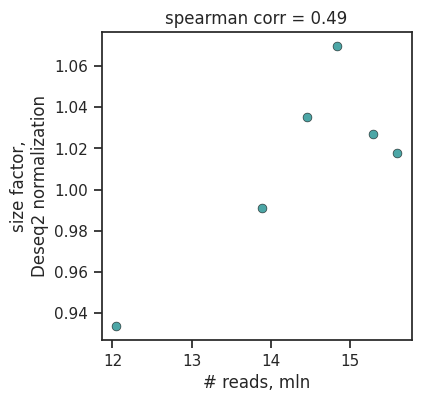

In [247]:
plot_size_factors(sfs_df,savefig_path='./tests/plots/library_size_vs_SF.png')

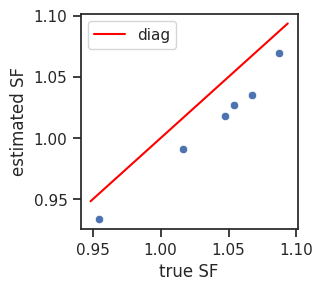

In [249]:
sfs_df['true_sf'] = nb_true_sf
sns.set(font_scale=1, style="white")
fig, axes = plt.subplots(1, 1, figsize=(2.8, 2.8))
ax = sns.scatterplot(data = sfs_df,x='true_sf',y='sf')
ax = sns.lineplot(data = pd.DataFrame([[ax.get_xlim()[0],ax.get_xlim()[0]],[ax.get_xlim()[1],ax.get_xlim()[1]]],columns=['true_sf','sf']),x='true_sf',y='sf',color='red',label='diag')
ax.set(xlabel='true SF',ylabel='estimated SF')
ax.tick_params(left=True, bottom=True)

### Mean-Variance Modeling and Confidence Intervals

In [250]:
# Model the condition-specific dispersion using Quantile Regression
regr_model_df, all_plot_data = model_mean_variance(
    norm_counts_df, 
    metadata_df, 
    sample_col='sample', 
    cond_col='condition'
)

print("\nRegression Model Parameters (Alpha/Dispersion):")
print(regr_model_df)


Regression Model Parameters (Alpha/Dispersion):
   condition model_type pred_feature     param
0    Control   QuantReg          var  0.030207
1  Treatment   QuantReg          var  0.034902


In [ ]:
# WARNING: param values should be very similar to the specified value of alpha (see above)!
# CURRENT status: it does not match

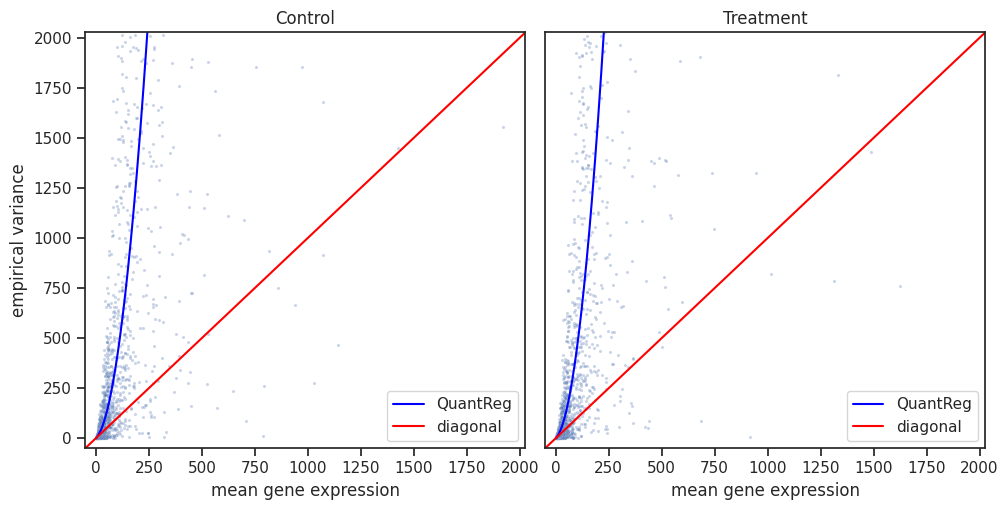

In [251]:
# Plot the diagnostic regression fits for variance within each condition
plot_mean_variance_diagnostics(
    all_plot_data, 
    savefig_path='./tests/plots/mean_variance_diagnostics.png'
)

## Sanity style normalization and quantification

In [320]:
# first, run Sanity without Empirical Bayes Shrinkage (as in the original paper)
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=nb_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=False,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2941 genes using 5 cores...
PASS 3: Finalizing Bayesian Posteriors...
Sanity normalization complete.


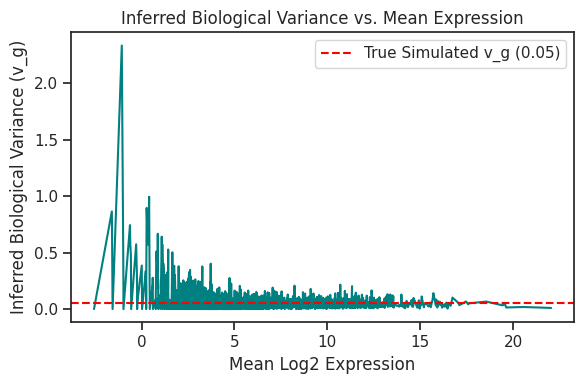

In [321]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.without_Empir_Bayes_Shrinkage.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

In [332]:
# now, run Sanity with Empirical Bayes Shrinkage that takes advantage of mean-variance relatioship across genes
sanity_norm_counts_df, sanity_means_df, sanity_errors_df, sanity_vg_df = apply_sanity_normalization(
    counts_df=nb_counts_df, 
    metadata_df=metadata_df, 
    sample_col='sample', 
    cond_col='condition',
    empirical_bayes=True,
    n_cores=5,
)

PASS 1: Running Sanity inference on 2941 genes using 5 cores...
PASS 2: Applying Empirical Bayes Variance Shrinkage (Overdispersion-Only Fit)...
PASS 3: Finalizing Bayesian Posteriors...


/scicore/home/zavolan/mirono0000/miniforge3_Dec2024/envs/zavolab_pyutils/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Sanity normalization complete.


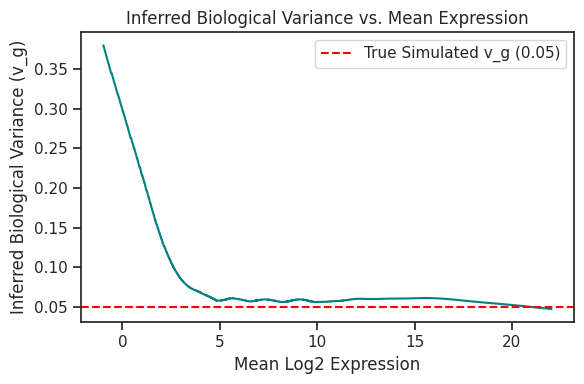

In [333]:
plot_variance_vs_expression(
    sanity_means_df, sanity_vg_df, 
    savefig_path='./tests/plots/variance_vs_expr.png',
    true_vg=0.05 # This is to compare with True value specified during simulation above
)

## Diagnostic plots for expression normalization confounders

these make more sense at larger number of replicates, like >15, because otherwise observed between-bioreplicate variance is mostly just technical noise

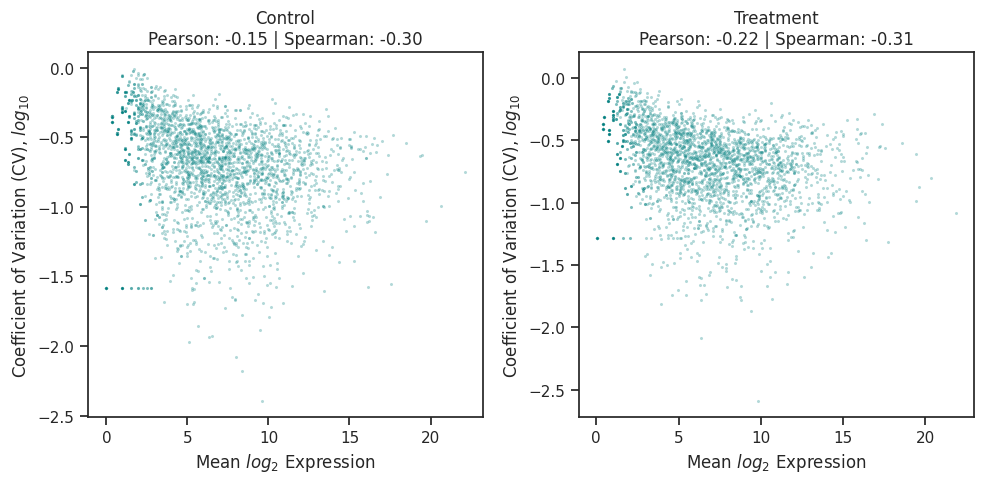

In [334]:
# 1. DESeq2 Mean vs CV (is_log2 = False because norm_counts is on raw scale)
deseq_plot_data = plot_mean_vs_cv(
    norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_deseq2.png', 
    is_log2=False
)

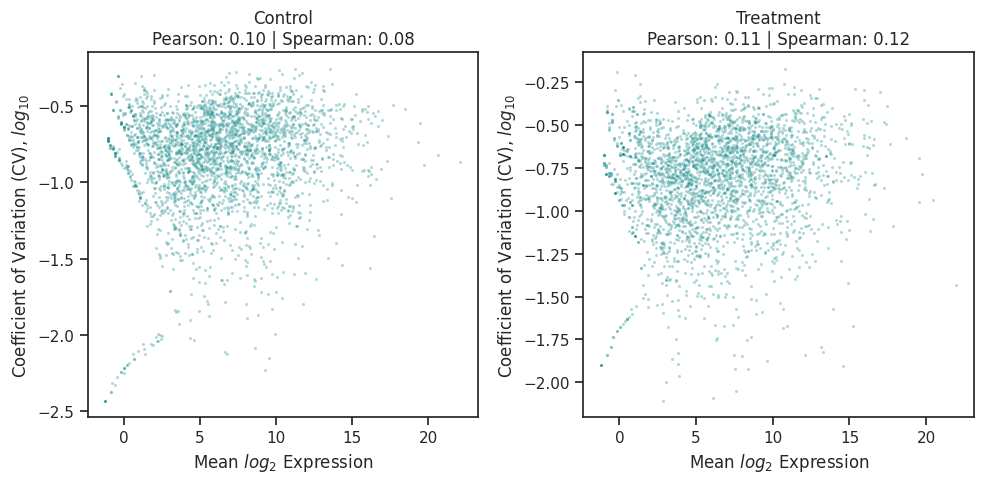

In [335]:
# 2. Sanity Mean vs CV (is_log2 = True to convert log2 back to raw for CV math)
sanity_plot_data = plot_mean_vs_cv(
    sanity_norm_counts_df, metadata_df, 
    savefig_path='./tests/plots/cv_plot_sanity.png', 
    is_log2=True
)

## Differential expression testing based on Sanity's and Mean-variance QuantReg modelling (DESeq2-like) output

### Sanity

In [342]:
sanity_DE_df = test_differential_expression(
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    cond_A="Treatment", 
    cond_B="Control"
)

In [378]:
# False discovery rate is:
len(sanity_DE_df.loc[sanity_DE_df['padj']<0.05])/len(sanity_DE_df)

0.013600816048962938

### mean-variance modelling with QuantReg

In [353]:
# 1. Extract exact means and standard errors using the fitted QuantReg alpha
deseq_means_df, deseq_errors_df = get_deseq2_means_and_errors(
    norm_counts_df=norm_counts_df, 
    metadata_df=metadata_df, 
    regr_model_df=regr_model_df
)

In [354]:
deseq_DE_df = test_differential_expression(
    means_df=deseq_means_df, 
    errors_df=deseq_errors_df, 
    cond_A="Treatment", 
    cond_B="Control"
)

In [355]:
# False discovery rate is:
len(deseq_DE_df.loc[deseq_DE_df['padj']<0.05])/len(deseq_DE_df)

0.0

In [377]:
deseq_DE_df['padj'].min()

np.float64(0.47520613158068)

## Plottting expression of individual genes with confidence intervals

In [371]:
selected_genes = ["Gene_1", "Gene_2", "Gene_3"]

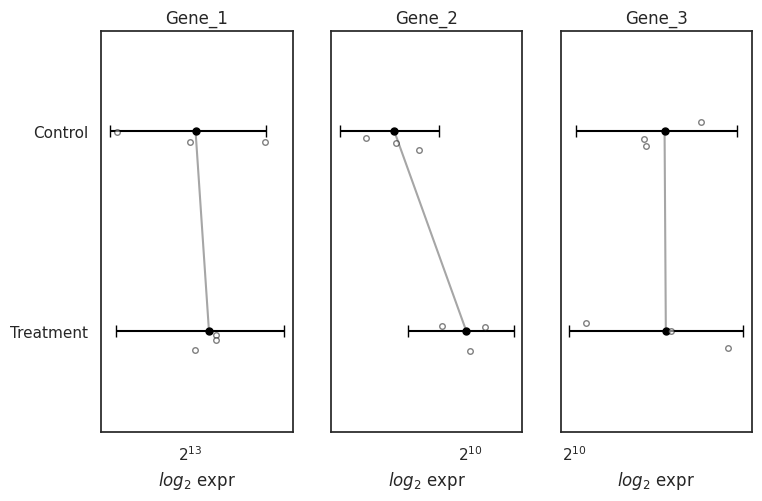

In [375]:
plot_gene_expression_with_ci(
    norm_counts_df=norm_counts_df, 
    means_df=deseq_means_df, 
    errors_df=deseq_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    savefig_path='./tests/plots/deseq_expression_ci.png',
    adjust_multiple_comparisons=True, # Optional Bonferroni adjustment
    log_scale=True,                    # Visually condenses the linear x-axis
)

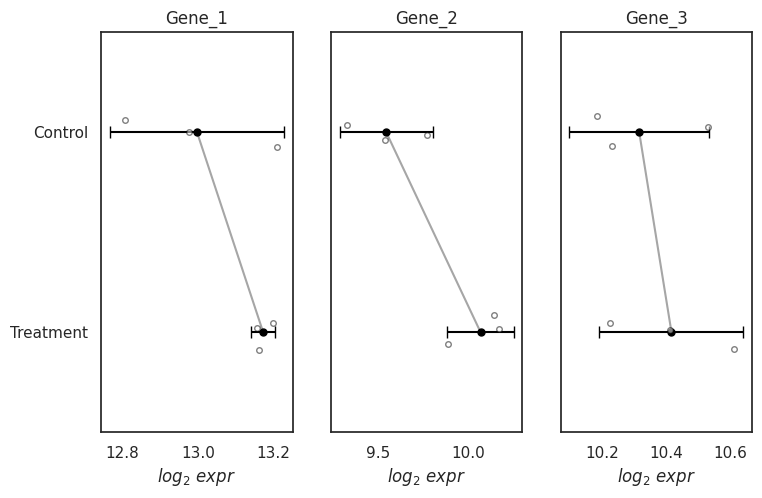

In [376]:
plot_sanity_gene_expression_with_ci(
    sample_norm_df=sanity_norm_counts_df, 
    means_df=sanity_means_df, 
    errors_df=sanity_errors_df, 
    metadata_df=metadata_df, 
    selected_genes=selected_genes, 
    adjust_multiple_comparisons=True,
    savefig_path='./tests/plots/sanity_expression_ci.png'
)